# Step 1: Data Understanding, Analysis, Visualization and Cleaning

## Dataset Description

The dataset utilised in this project was obtained from the International Skin Imaging Collaboration (ISIC) and is publicly available on Kaggle under the title **"Skin Cancer 9 Classes ISIC"**.

Dataset Link:  
https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic

The dataset is organised into two primary directories:

- **Train** – contains labelled dermoscopic images arranged into separate class-wise folders.
- **Test** – includes unlabelled images used for inference and model evaluation.

Each folder inside the **Train** directory represents a specific skin lesion category and contains images in standard formats such as `.jpg` and `.png`.



The dataset consists of the following nine categories:

1. Actinic Keratosis  
2. Basal Cell Carcinoma  
3. Dermatofibroma  
4. Melanoma  
5. Nevus  
6. Pigmented Benign Keratosis  
7. Seborrheic Keratosis  
8. Squamous Cell Carcinoma  
9. Vascular Lesion

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import zipfile



# ZIP file path
zip_file = "/content/drive/MyDrive/dataset/Skin Cancer Classification-20260509T092546Z-3-001.zip"

# Extract location (fast local SSD)
extract_path = "/content/skin_cancer_dataset"

# Unzip dataset
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")



Dataset extracted successfully!


In [5]:
# GET TRAIN AND TEST DIRECTORY

train_dir = "/content/skin_cancer_dataset/Skin Cancer Classification/Train"
test_dir = "/content/skin_cancer_dataset/Skin Cancer Classification/Test"

# Class names
class_names = sorted(os.listdir(train_dir))

print(f"Found {len(class_names)} classes:")
print(class_names)

Found 9 classes:
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [8]:
# CHECK FOR CURROPTED IMAGE IN TRAINING FOLDER
from PIL import Image
import pathlib

bad_files = []

# Scan all training folders
for folder in pathlib.Path(train_dir).iterdir():

    if folder.is_dir():

        for image_file in folder.glob("*"):

            try:
                # Open and force-read image
                image = Image.open(image_file)
                image.convert("RGB")

            except Exception as err:
                bad_files.append({
                    "file": str(image_file),
                    "issue": str(err)
                })

# Display results
if len(bad_files) > 0:

    print(f"Detected {len(bad_files)} problematic images:\n")

    for item in bad_files:
        print(f"File: {item['file']}")


else:
    print("Dataset check completed — no damaged images found.")

Detected 63 problematic images:

File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0028449.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0026867.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027770.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027151.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027680.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0024626.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0025777.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/melanoma/ISIC_0010486.jpg
File: /content/skin_cancer_dataset/Skin Cancer Classification/Train/melanoma/ISIC_0000308

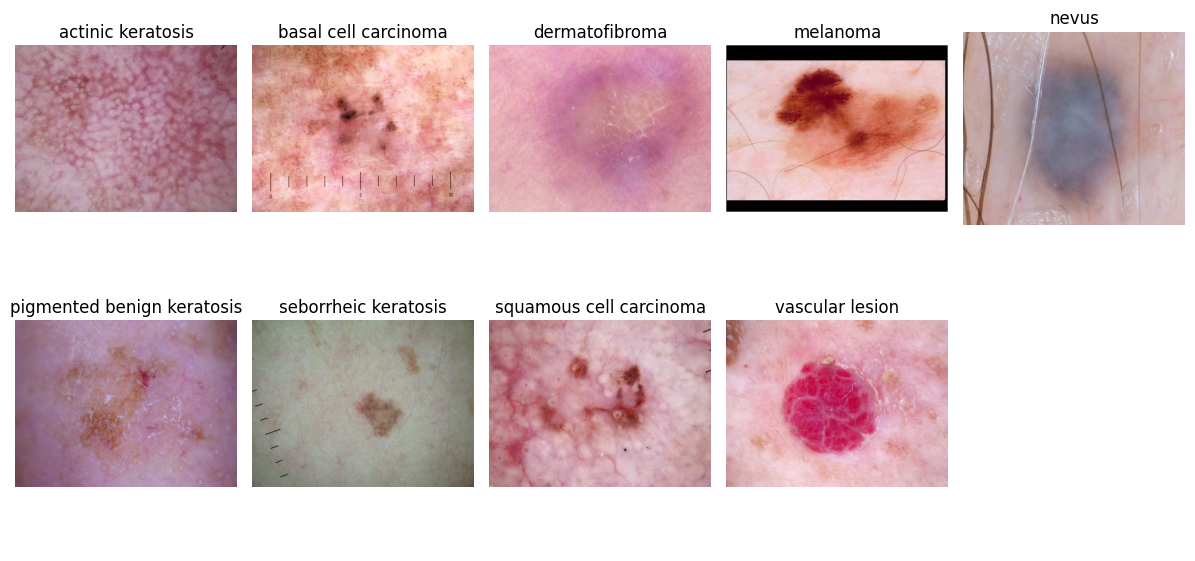

In [9]:
# DATASET VISUALIZATION AD DISPLAY USING MATPLOTLIB 1 IMAGE PER CLASS
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
selected_images = []
selected_labels = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
# Counts number of images in each class folder for train and test sets, creates a summary table, and displays dataset distribution and totals.

import os
import pandas as pd

def get_counts(path):
    results = {}

    for folder in os.scandir(path):

        if folder.is_dir():
            images = [
                img.name for img in os.scandir(folder.path)
                if img.name.lower().endswith((".png", ".jpg", ".jpeg"))
            ]
            results[folder.name] = len(images)

    return results


# count images
train_stats = get_counts(train_dir)
test_stats = get_counts(test_dir)

# create dataframe
summary = pd.DataFrame({
    "Train": pd.Series(train_stats),
    "Test": pd.Series(test_stats)
}).fillna(0).astype(int)

summary["Total"] = summary["Train"] + summary["Test"]

summary = summary.sort_values(by="Total", ascending=False)

print(summary)

print("\nTotal Train Images:", summary["Train"].sum())
print("Total Test Images:", summary["Test"].sum())


                            Train  Test  Total
pigmented benign keratosis    462    16    478
melanoma                      438    16    454
basal cell carcinoma          376    16    392
nevus                         357    16    373
squamous cell carcinoma       181    16    197
vascular lesion               139     3    142
actinic keratosis             114    16    130
dermatofibroma                 95    16    111
seborrheic keratosis           77     3     80

Total Train Images: 2239
Total Test Images: 118


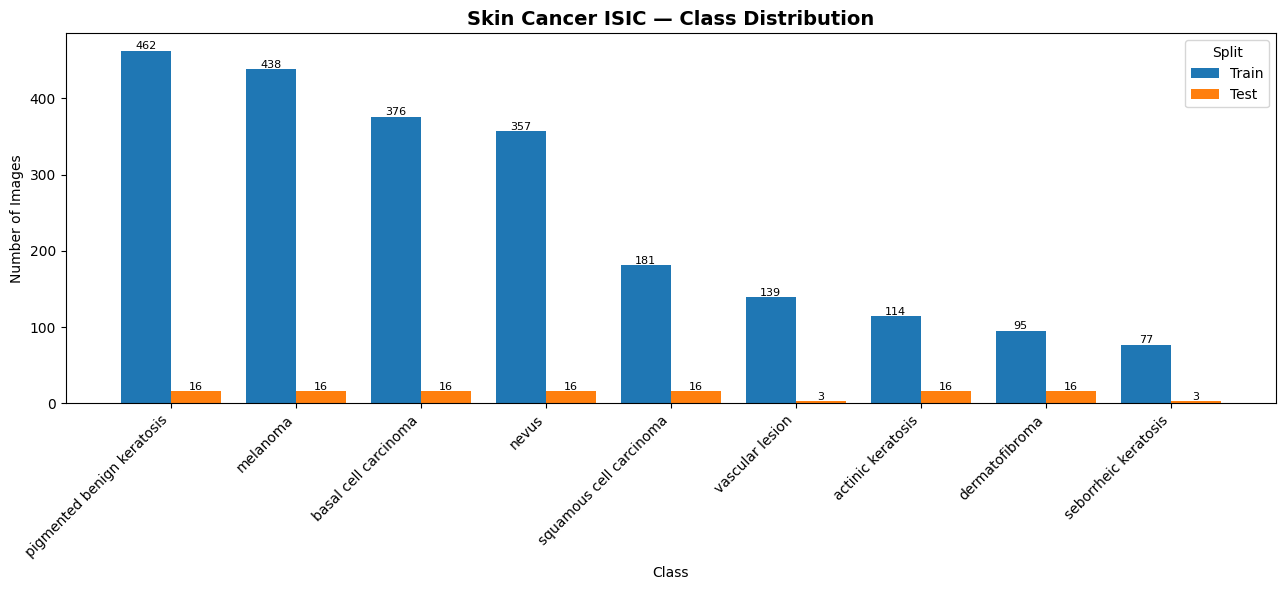

In [15]:
# Bar chart visualization of your dataset using Matplotlib and Pandas.

import os
import pandas as pd
import matplotlib.pyplot as plt


import numpy as np

df_plot = df.copy()
classes = df_plot.index.tolist()

x = np.arange(len(classes))
width = 0.4

plt.figure(figsize=(13, 6))

# side-by-side bars
plt.bar(x - width/2, df_plot["Train"], width, label="Train")
plt.bar(x + width/2, df_plot["Test"], width, label="Test")

plt.title("Skin Cancer ISIC — Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(x, classes, rotation=45, ha="right")
plt.legend(title="Split")

# value labels
for i in range(len(classes)):
    plt.text(x[i] - width/2, df_plot["Train"].iloc[i] + 2,
             str(df_plot["Train"].iloc[i]), ha="center", fontsize=8)

    plt.text(x[i] + width/2, df_plot["Test"].iloc[i] + 2,
             str(df_plot["Test"].iloc[i]), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

 **Based on the dataset structure from ISIC:**


*   Dataset is highly imbalanced
*   Majority classes: nevus, melanoma, pigemented
*   Minority classes: dermatofibroma, actinic keratosis, vascular lesions
*   This can bias model performance

**To fix this**

*   Class-weighted loss
*   Data augmentation (minority classes)
*   Oversampling techniques





        










In [16]:
# Analyze  image dataset to understand image size distribution and data quality
from PIL import Image
import numpy as np
from pathlib import Path

width_list = []
height_list = []
bad_images = []

train_path = Path(train_dir)

# iterate through all images using pathlib style
for img_path in train_path.rglob("*"):

    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        try:
            with Image.open(img_path) as im:
                im.verify()  # check corruption

            with Image.open(img_path) as im:
                w, h = im.size
                width_list.append(w)
                height_list.append(h)

        except Exception:
            bad_images.append(str(img_path))

# statistics
print("Width stats:")
print("Min:", np.min(width_list))
print("Max:", np.max(width_list))
print("Mean:", np.mean(width_list))

print("\nHeight stats:")
print("Min:", np.min(height_list))
print("Max:", np.max(height_list))
print("Mean:", np.mean(height_list))

print("\nAll images same size:", len(set(zip(width_list, height_list))) == 1)
print("Unreadable images:", len(bad_images))

Width stats:
Min: 576
Max: 3872
Mean: 864.7155330882352

Height stats:
Min: 450
Max: 2592
Mean: 652.7817095588235

All images same size: False
Unreadable images: 63


In [18]:
# basic configuration for a deep learning image model using TensorFlow and Keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

In [21]:
# Loads training, validation, and test datasets from directory structure, applies resizing, batching, categorical labeling, and computes dataset metadata like class names and step counts for training setup.

import tensorflow as tf

# create train + validation split automatically
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# test dataset (no split, no shuffle)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# class info
class_names = train_ds.class_names
num_classes = len(class_names)

# dataset sizes
train_steps = len(train_ds)
val_steps = len(val_ds)

print("Number of classes:", num_classes)
print("Class names:", class_names)
print("Train steps per epoch:", train_steps)
print("Validation steps:", val_steps)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Found 2239 files belonging to 9 classes.
Using 447 files for validation.
Found 118 files belonging to 9 classes.
Number of classes: 9
Class names: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train steps per epoch: 56
Validation steps: 14


In [22]:
# Defines two image augmentation pipelines: one for light transformations (for majority classes) and one for stronger transformations (for minority classes) to improve model generalization and handle dataset imbalance.


# light augmentation (minimal changes)
mild_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

# heavy augmentation (aggressive variations)
strong_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3)
])

In [23]:
# Computes class-wise image counts, calculates dataset imbalance using average frequency,
# and separates minority and majority classes to guide augmentation strategy.

import os
import numpy as np
import tensorflow as tf

# count images per class
class_counts = {}

for class_name in class_names:
    folder = os.path.join(train_dir, class_name)

    class_counts[class_name] = sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

# compute average class size
avg_count = np.mean(list(class_counts.values()))

# identify minority classes (below average)
minority_classes = [
    class_names.index(name)
    for name, count in class_counts.items()
    if count < avg_count
]

minority_indices = tf.constant(minority_classes, dtype=tf.int32)

# display results
print(f"Average class size: {avg_count:.0f}")

print("\nMinority classes (need strong augmentation):")
for name, count in class_counts.items():
    if count < avg_count:
        print(f"{name:30s} : {count}")

print("\nMajority classes (mild augmentation):")
for name, count in class_counts.items():
    if count >= avg_count:
        print(f"{name:30s} : {count}")

Average class size: 249

Minority classes (need strong augmentation):
actinic keratosis              : 114
dermatofibroma                 : 95
seborrheic keratosis           : 77
squamous cell carcinoma        : 181
vascular lesion                : 139

Majority classes (mild augmentation):
basal cell carcinoma           : 376
melanoma                       : 438
nevus                          : 357
pigmented benign keratosis     : 462


In [27]:
# Applies class-aware augmentation safely by ensuring consistent tensor dtypes
# and using strong augmentation for minority classes and mild for majority classes.

import tensorflow as tf

def adaptive_augment(images, labels):

    # convert labels → class indices
    class_ids = tf.argmax(labels, axis=1)

    # FIX: ensure same dtype for comparison
    class_ids = tf.cast(class_ids, tf.int32)
    minority_idx = tf.cast(minority_indices, tf.int32)

    # detect minority samples
    minority_mask = tf.reduce_any(
        tf.equal(
            tf.expand_dims(class_ids, 1),
            tf.expand_dims(minority_idx, 0)
        ),
        axis=1
    )

    # apply augmentations
    aug_strong = strong_augmentation(images, training=True)
    aug_mild = mild_augmentation(images, training=True)

    # choose augmentation based on class type
    images = tf.where(
        tf.reshape(minority_mask, (-1, 1, 1, 1)),
        aug_strong,
        aug_mild
    )

    return images, labels

In [28]:
# Builds optimized TensorFlow input pipelines for training, validation, and testing:
# includes error handling, caching, shuffling, augmentation, normalization, parallel processing, and prefetching for efficient model training.

import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# keep original validation reference
raw_val_ds = val_ds

# ---------------- Training pipeline ----------------
train_ds = (
    train_ds
    .apply(tf.data.experimental.ignore_errors())
    .cache()
    .shuffle(1000, seed=SEED)
    .repeat()
    .map(adaptive_augment, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# ---------------- Validation pipeline ----------------
val_ds = (
    val_ds
    .apply(tf.data.experimental.ignore_errors())
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .cache()
    .repeat()
    .prefetch(AUTOTUNE)
)

# ---------------- Test pipeline ----------------
test_ds = (
    raw_val_ds
    .apply(tf.data.experimental.ignore_errors())
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# ---------------- Summary ----------------
print("Pipeline ready for training.")
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)

Pipeline ready for training.
Steps per epoch: 56
Validation steps: 14


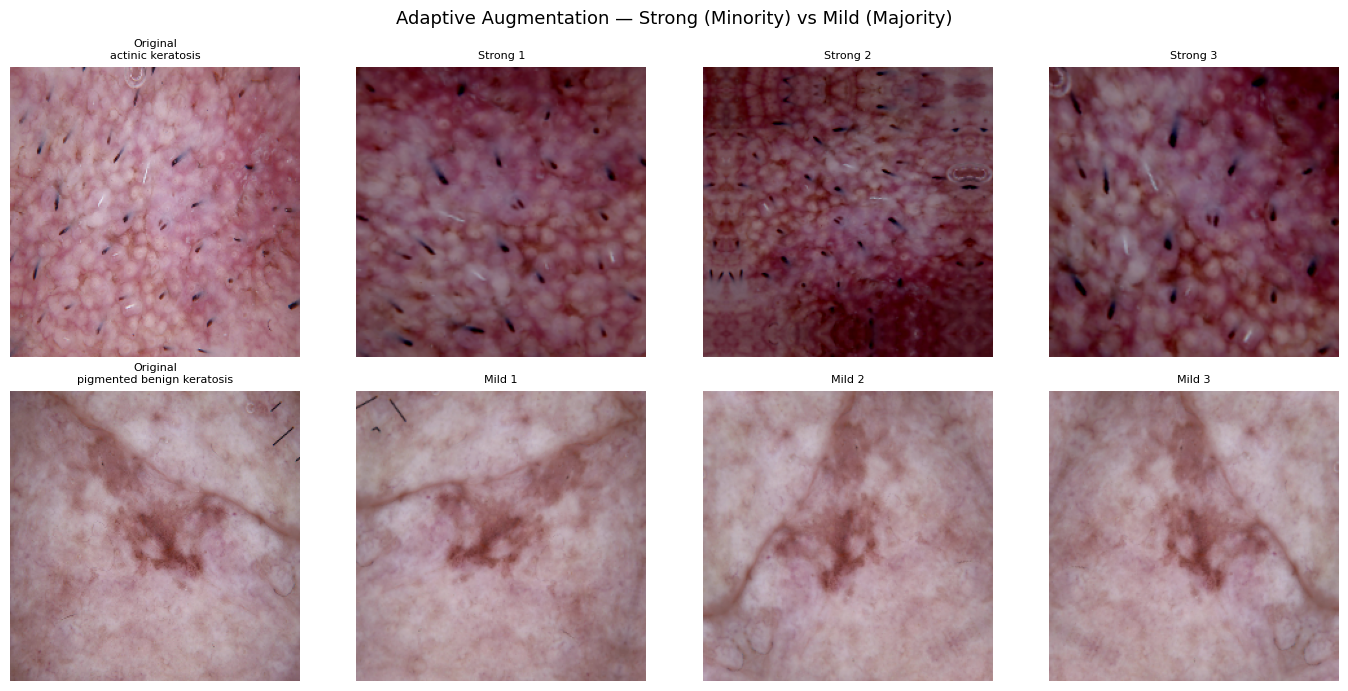

In [29]:
# Visualizes adaptive augmentation by comparing strong augmentation (minority class)
# and mild augmentation (majority class) using sample images from each category.

import os
import tensorflow as tf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Adaptive Augmentation — Strong (Minority) vs Mild (Majority)", fontsize=13)

# identify minority and majority classes
minority_class = next(c for c, v in class_counts.items() if v < avg_count)
majority_class = max(class_counts, key=class_counts.get)

# load one sample image from a class
def get_sample_image(class_name):
    path = os.path.join(train_dir, class_name)
    file_name = os.listdir(path)[0]

    img = tf.keras.preprocessing.image.load_img(
        os.path.join(path, file_name),
        target_size=IMG_SIZE
    )

    return tf.keras.preprocessing.image.img_to_array(img)

min_img = get_sample_image(minority_class)
maj_img = get_sample_image(majority_class)

# ---------------- Minority (strong augmentation) ----------------
axes[0, 0].imshow(min_img.astype("uint8"))
axes[0, 0].set_title(f"Original\n{minority_class}", fontsize=8)
axes[0, 0].axis("off")

for i in range(1, 4):
    aug = strong_augmentation(tf.expand_dims(min_img, 0), training=True)
    axes[0, i].imshow(aug[0].numpy().astype("uint8"))
    axes[0, i].set_title(f"Strong {i}", fontsize=8)
    axes[0, i].axis("off")

# ---------------- Majority (mild augmentation) ----------------
axes[1, 0].imshow(maj_img.astype("uint8"))
axes[1, 0].set_title(f"Original\n{majority_class}", fontsize=8)
axes[1, 0].axis("off")

for i in range(1, 4):
    aug = mild_augmentation(tf.expand_dims(maj_img, 0), training=True)
    axes[1, i].imshow(aug[0].numpy().astype("uint8"))
    axes[1, i].set_title(f"Mild {i}", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("adaptive_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# **Step 2: Implementing a baseline CNN model architecture**


In [30]:
# Defines a baseline CNN model for multi-class image classification using convolutional layers,
# followed by dense layers, and compiles it with Adam optimizer and evaluation metrics.

import tensorflow as tf
from tensorflow.keras import layers, models

# ---------------- CNN Model ----------------
baseline_model = models.Sequential()

# Block 1
baseline_model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
baseline_model.add(layers.MaxPooling2D((2, 2)))

# Block 2
baseline_model.add(layers.Conv2D(64, (3, 3), activation="relu"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

# Block 3
baseline_model.add(layers.Conv2D(128, (3, 3), activation="relu"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

# Fully connected layers
baseline_model.add(layers.Flatten())
baseline_model.add(layers.Dense(256, activation="relu"))
baseline_model.add(layers.Dense(128, activation="relu"))
baseline_model.add(layers.Dense(64, activation="relu"))

# Output layer (multi-class classification)
baseline_model.add(layers.Dense(9, activation="softmax"))

# ---------------- Compile model ----------------
baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ---------------- Summary ----------------
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,409 (85.02 MB)

 Trainable params: 22,286,409 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Computes class weights to handle dataset imbalance by giving higher importance to minority classes
# during training, improving model fairness and reducing bias toward majority classes.

import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# build label list from dataset structure
y_labels = []

for idx, class_name in enumerate(class_names):
    folder = os.path.join(train_dir, class_name)

    count = sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    y_labels.extend([idx] * count)

y_labels = np.array(y_labels)

# compute balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_labels),
    y=y_labels
)

class_weight_dict = {i: w for i, w in enumerate(weights)}

# display results
print("Computed Class Weights:\n")

for i, name in enumerate(class_names):
    print(f"{name:30s} : {class_weight_dict[i]:.4f}")

Computed Class Weights:

actinic keratosis              : 2.1823
basal cell carcinoma           : 0.6616
dermatofibroma                 : 2.6187
melanoma                       : 0.5680
nevus                          : 0.6969
pigmented benign keratosis     : 0.5385
seborrheic keratosis           : 3.2309
squamous cell carcinoma        : 1.3745
vascular lesion                : 1.7898


In [ ]:
# Trains the CNN model using class-balanced learning, early stopping, and tracks training time for performance evaluation.

import time
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

start_time = time.time()

# model training
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

# training time
training_time = time.time() - start_time

print(f"Training completed in {training_time/60:.2f} minutes")

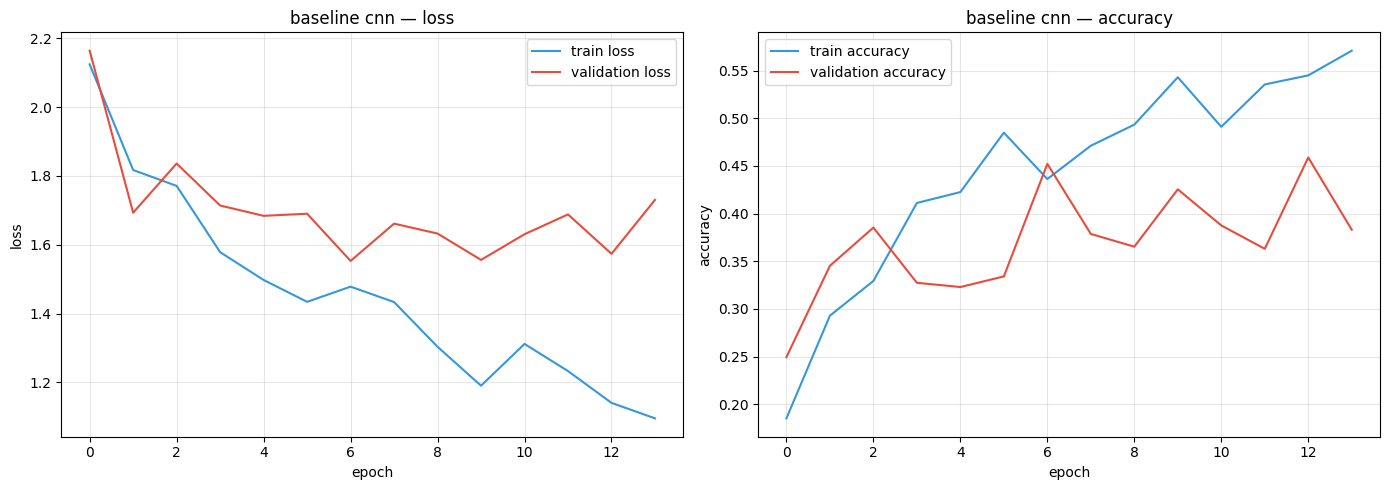

In [ ]:
# Visualizes training performance of the CNN model by plotting loss and accuracy curves
# for both training and validation sets over epochs.

import matplotlib.pyplot as plt

# create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Loss curve ----------------
axes[0].plot(history_baseline.history["loss"], label="Train Loss", color="blue")
axes[0].plot(history_baseline.history["val_loss"], label="Validation Loss", color="red")
axes[0].set_title("Baseline CNN - Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------- Accuracy curve ----------------
axes[1].plot(history_baseline.history["accuracy"], label="Train Accuracy", color="blue")
axes[1].plot(history_baseline.history["val_accuracy"], label="Validation Accuracy", color="red")
axes[1].set_title("Baseline CNN - Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# save figure
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
# Evaluates the trained CNN model on the test dataset using predictions,
# then generates a detailed classification report (precision, recall, f1-score per class).

import numpy as np
from sklearn.metrics import classification_report

# get model predictions
y_pred = np.argmax(baseline_model.predict(test_ds), axis=1)

# get true labels from dataset
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

# classification metrics report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        10
      basal cell carcinoma       0.30      0.46      0.36        35
            dermatofibroma       0.12      0.36      0.18        11
                  melanoma       0.51      0.72      0.60        50
                     nevus       0.68      0.33      0.45        45
pigmented benign keratosis       0.63      0.56      0.59        59
      seborrheic keratosis       0.00      0.00      0.00         7
   squamous cell carcinoma       0.00      0.00      0.00        23
           vascular lesion       0.81      0.76      0.79        17

                  accuracy                           0.46       257
                 macro avg       0.34      0.36      0.33       257
              weighted avg       0.47      0.46      0.44       257



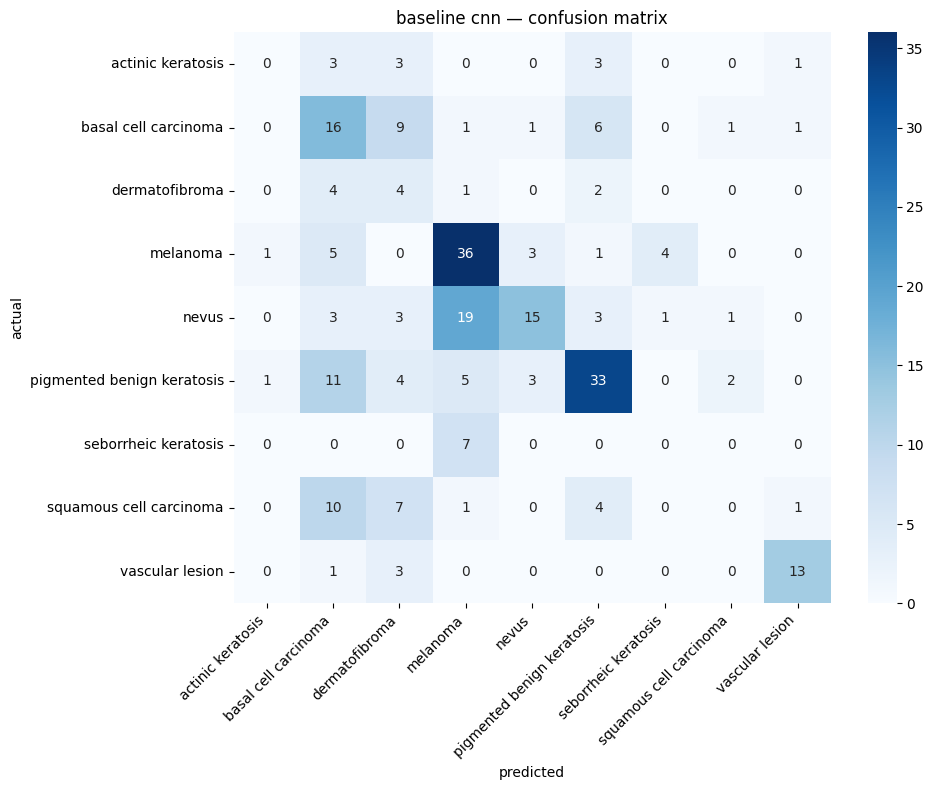

In [ ]:
# Plots confusion matrix for the trained CNN model predictions on the test set
# to evaluate class-wise performance and misclassification patterns.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# save figure
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")

plt.show()

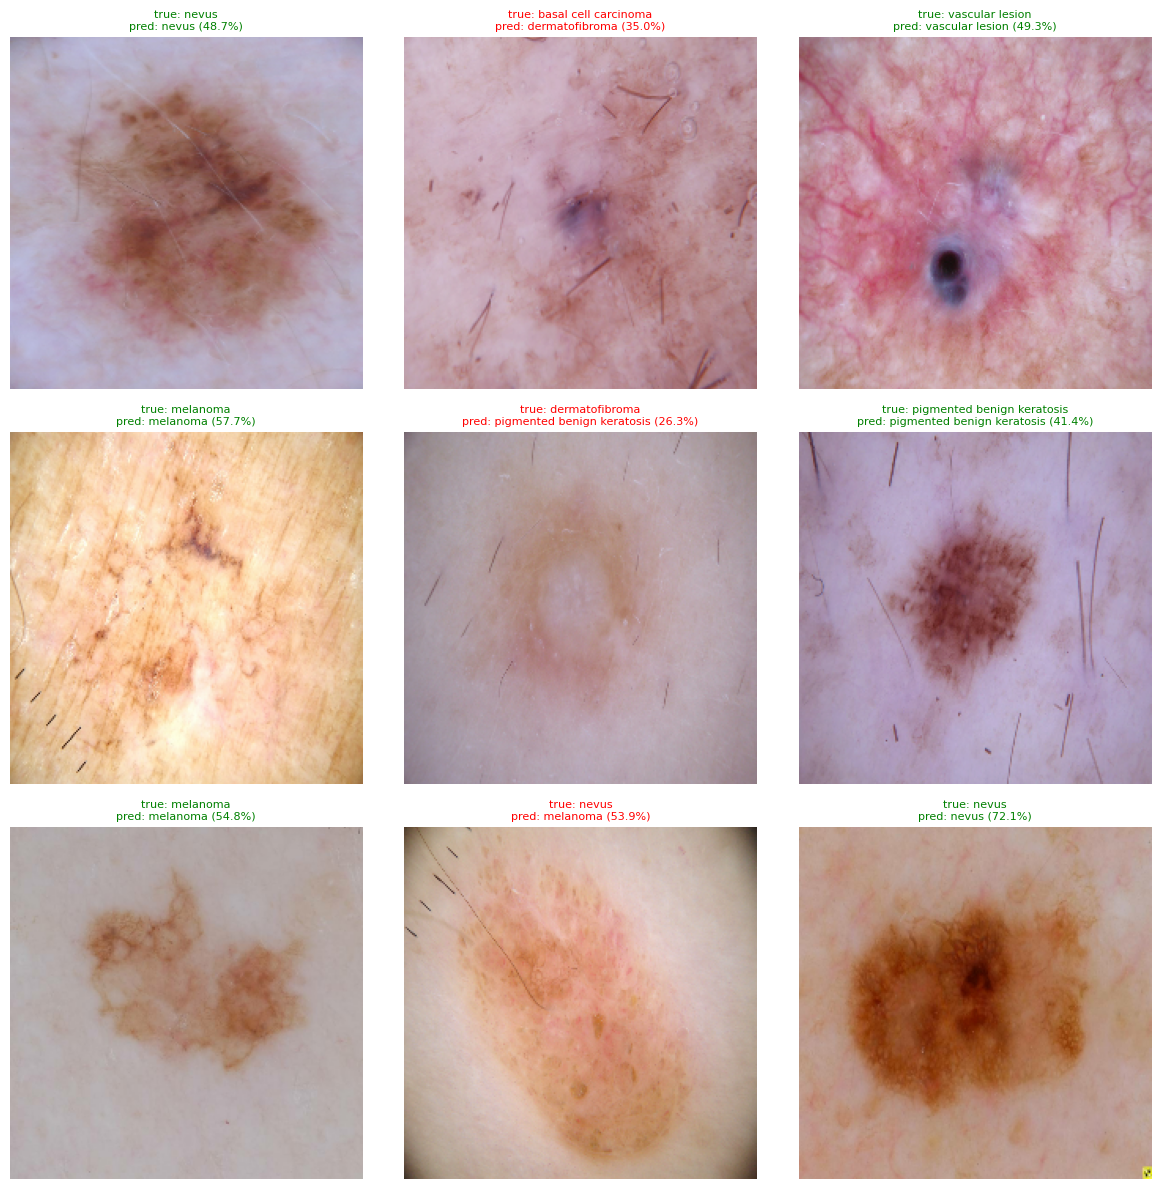

In [ ]:
# Visualizes model predictions on sample test images by comparing true vs predicted labels
# along with confidence scores to analyze model performance qualitatively.

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# take one batch from test dataset
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    true_labels = np.argmax(labels.numpy(), axis=1)

    preds = baseline_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

# display results
for i, ax in enumerate(axes.flat):

    img = (sample_images[i] * 255).astype("uint8")

    true_name = class_names[true_labels[i]]
    pred_name = class_names[pred_labels[i]]
    confidence = preds[i][pred_labels[i]] * 100

    ax.imshow(img)
    ax.axis("off")

    color = "green" if true_name == pred_name else "red"

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color=color
    )

plt.tight_layout()

plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")

plt.show()

# **2.5.3 Deeper Architecture with Regularization Layer:**

In [ ]:
# Defines a deeper CNN architecture with multiple convolutional blocks, batch normalization,
# dropout regularization, and global average pooling for improved feature extraction and generalization.

import tensorflow as tf
from tensorflow.keras import layers, models

# ---------------- Deep CNN Model ----------------
deeper_model = models.Sequential(name="deeper_cnn")

# Block 1
deeper_model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
deeper_model.add(layers.BatchNormalization())
deeper_model.add(layers.MaxPooling2D((2, 2)))

# Block 2
deeper_model.add(layers.Conv2D(64, (3, 3), activation="relu"))
deeper_model.add(layers.BatchNormalization())
deeper_model.add(layers.MaxPooling2D((2, 2)))

# Block 3
deeper_model.add(layers.Conv2D(128, (3, 3), activation="relu"))
deeper_model.add(layers.BatchNormalization())
deeper_model.add(layers.MaxPooling2D((2, 2)))

# Block 4
deeper_model.add(layers.Conv2D(256, (3, 3), activation="relu"))
deeper_model.add(layers.BatchNormalization())
deeper_model.add(layers.MaxPooling2D((2, 2)))

# Block 5
deeper_model.add(layers.Conv2D(512, (3, 3), activation="relu"))
deeper_model.add(layers.BatchNormalization())
deeper_model.add(layers.MaxPooling2D((2, 2)))

# Block 6
deeper_model.add(layers.Conv2D(512, (3, 3), activation="relu"))
deeper_model.add(layers.BatchNormalization())

# ---------------- Classifier head ----------------
deeper_model.add(layers.GlobalAveragePooling2D())
deeper_model.add(layers.Dense(512, activation="relu"))
deeper_model.add(layers.Dropout(0.3))
deeper_model.add(layers.Dense(256, activation="relu"))
deeper_model.add(layers.Dropout(0.2))
deeper_model.add(layers.Dense(128, activation="relu"))

# output layer
deeper_model.add(layers.Dense(num_classes, activation="softmax"))

# ---------------- Compile ----------------
deeper_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ---------------- Summary ----------------
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,362,441 (16.64 MB)

 Trainable params: 4,359,433 (16.63 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
# Trains the deeper CNN model using class weights and early stopping,
# while tracking training time and number of completed epochs.

import time
from tensorflow.keras.callbacks import EarlyStopping

start_time = time.time()

history_deeper = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

training_time = time.time() - start_time

print(f"Deeper model training time: {training_time/60:.2f} minutes")
print(f"Epochs completed: {len(history_deeper.history['loss'])}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 223ms/step - accuracy: 0.3288 - loss: 1.8989 - precision: 0.4384 - recall: 0.1161 - val_accuracy: 0.1314 - val_loss: 2.9136 - val_precision: 0.1813 - val_recall: 0.0690
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3734 - loss: 1.6724 - precision: 0.5019 - recall: 0.1521 - val_accuracy: 0.1314 - val_loss: 4.0481 - val_precision: 0.1314 - val_recall: 0.1314
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.4258 - loss: 1.5689 - precision: 0.5881 - recall: 0.1955 - val_accuracy: 0.1314 - val_loss: 3.3657 - val_precision: 0.1314 - val_recall: 0.1314
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.4477 - loss: 1.4828 - precision: 0.5765 - recall: 0.2327 - val_accuracy: 0.1314 - val_loss: 2.6742 - val_precision: 0.2064 - val_recall: 0.1292
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4357 - loss: 1.4858 - precision: 0.5731 - recall: 0.2196 - val_accuracy: 0.0913 - val_loss: 3.603

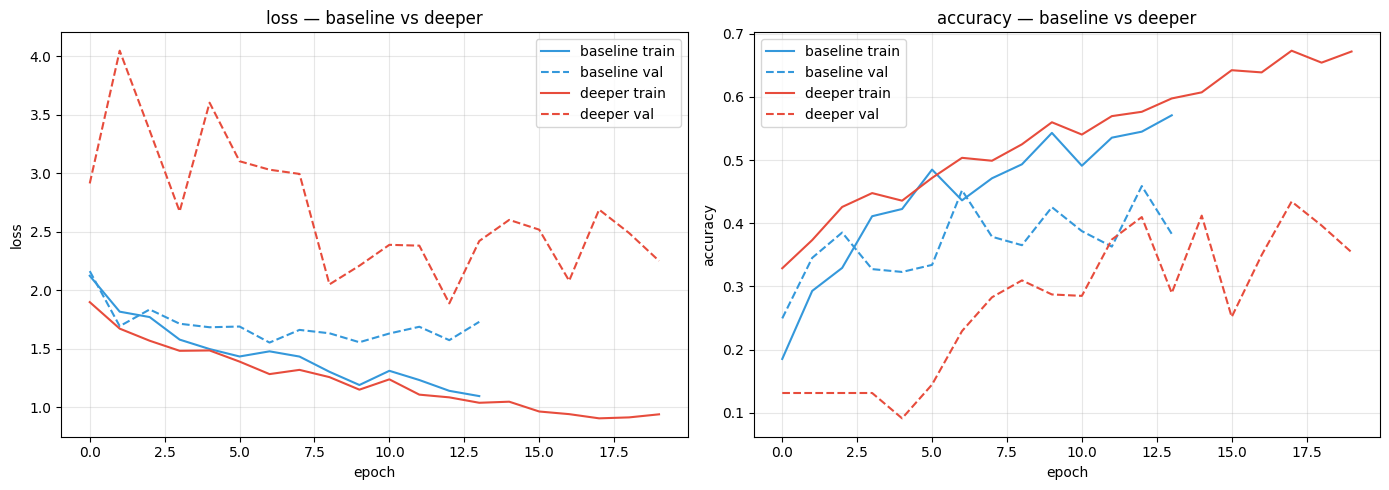

In [ ]:
# Compares training performance of baseline vs deeper CNN models using loss and accuracy curves
# to analyze improvements in convergence and generalization.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Loss comparison ----------------
axes[0].plot(history_baseline.history["loss"], label="Baseline Train", color="blue")
axes[0].plot(history_baseline.history["val_loss"], label="Baseline Val", linestyle="--", color="blue")

axes[0].plot(history_deeper.history["loss"], label="Deeper Train", color="red")
axes[0].plot(history_deeper.history["val_loss"], label="Deeper Val", linestyle="--", color="red")

axes[0].set_title("Loss Comparison: Baseline vs Deeper CNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------- Accuracy comparison ----------------
axes[1].plot(history_baseline.history["accuracy"], label="Baseline Train", color="blue")
axes[1].plot(history_baseline.history["val_accuracy"], label="Baseline Val", linestyle="--", color="blue")

axes[1].plot(history_deeper.history["accuracy"], label="Deeper Train", color="red")
axes[1].plot(history_deeper.history["val_accuracy"], label="Deeper Val", linestyle="--", color="red")

axes[1].set_title("Accuracy Comparison: Baseline vs Deeper CNN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig("model_comparison_curves.png", dpi=150, bbox_inches="tight")

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


                            precision    recall  f1-score   support

         actinic keratosis       0.33      0.10      0.15        10
      basal cell carcinoma       0.56      0.40      0.47        35
            dermatofibroma       0.09      0.09      0.09        11
                  melanoma       0.45      0.30      0.36        50
                     nevus       0.28      0.22      0.25        45
pigmented benign keratosis       0.42      0.76      0.54        59
      seborrheic keratosis       0.24      0.57      0.33         7
   squamous cell carcinoma       0.27      0.13      0.18        23
           vascular lesion       0.86      0.71      0.77        17

                  accuracy                           0.41       257
                 macro avg       0.39      0.36      0.35       257
              weighted avg       0.41      0.41      0.39       257



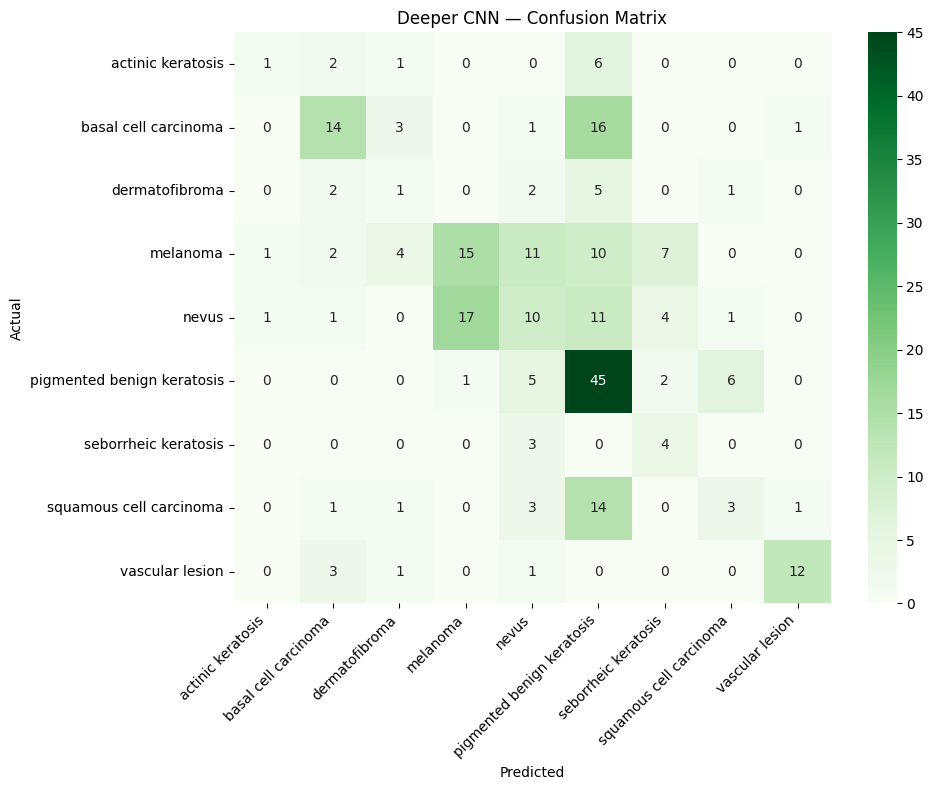

In [ ]:
# Evaluates the deeper CNN model on test data using classification metrics
# and visualizes performance using a confusion matrix.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# predictions from model
y_pred_deeper = np.argmax(deeper_model.predict(test_ds), axis=1)

# true labels from dataset
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

# classification report
print(
    classification_report(
        y_true,
        y_pred_deeper,
        target_names=class_names,
        zero_division=0
    )
)

# confusion matrix
cm = confusion_matrix(y_true, y_pred_deeper)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Deeper CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("deeper_confusion_matrix.png", dpi=150, bbox_inches="tight")

plt.show()

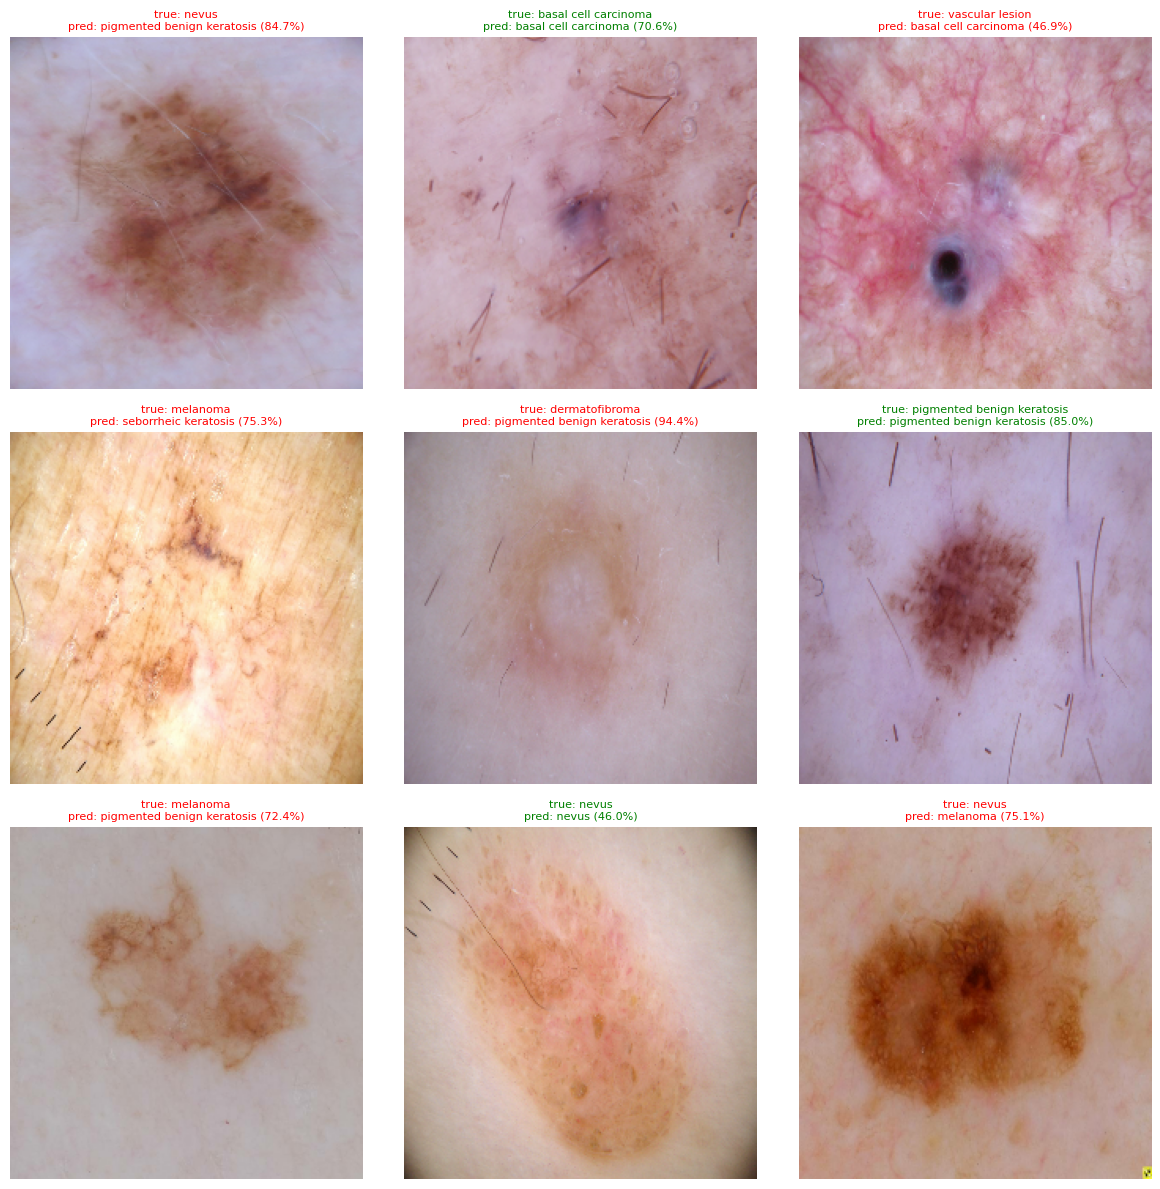

In [ ]:
# Displays sample predictions from the deeper CNN model by comparing true labels vs predicted labels
# along with confidence scores to visually evaluate model performance.

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# take one batch from test dataset
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    true_labels = np.argmax(labels.numpy(), axis=1)

    preds = deeper_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

# plot results
for i, ax in enumerate(axes.flat):

    img = (sample_images[i] * 255).astype("uint8")

    true_name = class_names[true_labels[i]]
    pred_name = class_names[pred_labels[i]]
    confidence = preds[i][pred_labels[i]] * 100

    ax.imshow(img)
    ax.axis("off")

    color = "green" if true_name == pred_name else "red"

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color=color
    )

plt.tight_layout()

plt.savefig("deeper_sample_predictions.png", dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
# Compares baseline and deeper CNN models using evaluation metrics on test data
# including accuracy, precision, recall, F1-score, and training time.

import numpy as np
import pandas as pd

# ---------------- Evaluate models ----------------
b_loss, b_acc, b_prec, b_rec = baseline_model.evaluate(test_ds, verbose=0)
d_loss, d_acc, d_prec, d_rec = deeper_model.evaluate(test_ds, verbose=0)

# ---------------- F1 score calculation ----------------
f1_b = (2 * b_prec * b_rec) / (b_prec + b_rec + 1e-7)
f1_d = (2 * d_prec * d_rec) / (d_prec + d_rec + 1e-7)

# ---------------- Create comparison table ----------------
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (min)"],

    "Baseline": [
        f"{b_acc:.4f}",
        f"{b_prec:.4f}",
        f"{b_rec:.4f}",
        f"{f1_b:.4f}",
        f"{baseline_training_time/60:.2f}"
    ],

    "Deeper": [
        f"{d_acc:.4f}",
        f"{d_prec:.4f}",
        f"{d_rec:.4f}",
        f"{f1_d:.4f}",
        f"{deeper_training_time/60:.2f}"
    ]
})

# ---------------- Display ----------------
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


              metric baseline deeper
            accuracy   0.4553 0.4086
           precision   0.6300 0.4774
              recall   0.2451 0.2879
            f1 score   0.3529 0.3592
training time (mins)     1.28   1.88


In [ ]:
# Compares optimizer performance by training a cloned deeper CNN model using SGD with momentum
# and evaluating training time and convergence behavior with early stopping.

import time
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# clone model architecture
deeper_model_sgd = tf.keras.models.clone_model(deeper_model)

# compile with SGD optimizer
deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

start_time = time.time()

# training
history_sgd = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

# timing
sgd_training_time = time.time() - start_time

print(f"SGD training time: {sgd_training_time/60:.2f} minutes")
print(f"Epochs completed: {len(history_sgd.history['loss'])}")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 226ms/step - accuracy: 0.3099 - loss: 1.9154 - precision: 0.4099 - recall: 0.0755 - val_accuracy: 0.0601 - val_loss: 3.6944 - val_precision: 0.1106 - val_recall: 0.0557
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4088 - loss: 1.6029 - precision: 0.5668 - recall: 0.1698 - val_accuracy: 0.1693 - val_loss: 2.2414 - val_precision: 0.1500 - val_recall: 0.0134
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.4281 - loss: 1.5472 - precision: 0.5574 - recall: 0.2001 - val_accuracy: 0.2450 - val_loss: 2.0561 - val_precision: 0.2577 - val_recall: 0.1114
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.4660 - loss: 1.4101 - precision: 0.6213 - recall: 0.2504 - val_accuracy: 0.2650 - val_loss: 2.1462 - val_precision: 0.3571 - val_recall: 0.1225
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.5169 - loss: 1.3530 - precision: 0.6613 - recall: 0.3082 - val_accuracy: 0.2138 - val_loss: 2.485

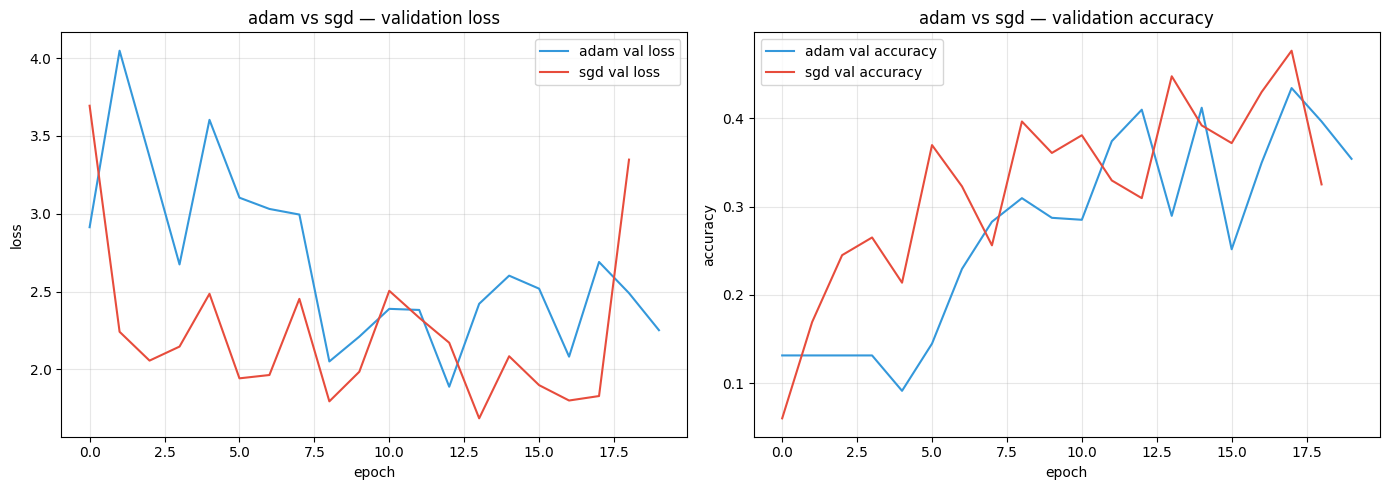

In [ ]:
# Compares performance of Adam vs SGD optimizers by plotting validation loss and accuracy curves
# to analyze convergence speed and stability differences.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Validation Loss ----------------
axes[0].plot(history_deeper.history["val_loss"], label="Adam Val Loss", color="blue")
axes[0].plot(history_sgd.history["val_loss"], label="SGD Val Loss", color="red")

axes[0].set_title("Adam vs SGD - Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------- Validation Accuracy ----------------
axes[1].plot(history_deeper.history["val_accuracy"], label="Adam Val Accuracy", color="blue")
axes[1].plot(history_sgd.history["val_accuracy"], label="SGD Val Accuracy", color="red")

axes[1].set_title("Adam vs SGD - Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig("adam_vs_sgd_comparison.png", dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
# Ablation study: trains a deeper CNN model without dropout layers to analyze the effect of regularization
# on overfitting, convergence, and generalization performance.

import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# ---------------- Model without dropout ----------------
deeper_model_no_dropout = models.Sequential(name="deeper_no_dropout")

deeper_model_no_dropout.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
deeper_model_no_dropout.add(layers.BatchNormalization())
deeper_model_no_dropout.add(layers.MaxPooling2D((2, 2)))

deeper_model_no_dropout.add(layers.Conv2D(64, (3, 3), activation="relu"))
deeper_model_no_dropout.add(layers.BatchNormalization())
deeper_model_no_dropout.add(layers.MaxPooling2D((2, 2)))

deeper_model_no_dropout.add(layers.Conv2D(128, (3, 3), activation="relu"))
deeper_model_no_dropout.add(layers.BatchNormalization())
deeper_model_no_dropout.add(layers.MaxPooling2D((2, 2)))

deeper_model_no_dropout.add(layers.Conv2D(256, (3, 3), activation="relu"))
deeper_model_no_dropout.add(layers.BatchNormalization())
deeper_model_no_dropout.add(layers.MaxPooling2D((2, 2)))

deeper_model_no_dropout.add(layers.Conv2D(512, (3, 3), activation="relu"))
deeper_model_no_dropout.add(layers.BatchNormalization())
deeper_model_no_dropout.add(layers.MaxPooling2D((2, 2)))

deeper_model_no_dropout.add(layers.Conv2D(512, (3, 3), activation="relu"))
deeper_model_no_dropout.add(layers.BatchNormalization())

# classifier head (NO dropout)
deeper_model_no_dropout.add(layers.Flatten())
deeper_model_no_dropout.add(layers.Dense(512, activation="relu"))
deeper_model_no_dropout.add(layers.Dense(256, activation="relu"))
deeper_model_no_dropout.add(layers.Dense(128, activation="relu"))
deeper_model_no_dropout.add(layers.Dense(num_classes, activation="softmax"))

# ---------------- Compile ----------------
deeper_model_no_dropout.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ---------------- Train ----------------
start_time = time.time()

history_no_dropout = deeper_model_no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

# ---------------- Timing ----------------
print(f"No dropout training time: {(time.time() - start_time)/60:.2f} minutes")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 214ms/step - accuracy: 0.3099 - loss: 2.2246 - precision: 0.3688 - recall: 0.1687 - val_accuracy: 0.1314 - val_loss: 4.1971 - val_precision: 0.1475 - val_recall: 0.1225
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3785 - loss: 1.7693 - precision: 0.4925 - recall: 0.2253 - val_accuracy: 0.1314 - val_loss: 3.7099 - val_precision: 0.1314 - val_recall: 0.1314
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.4142 - loss: 1.5790 - precision: 0.5241 - recall: 0.2332 - val_accuracy: 0.2094 - val_loss: 2.6081 - val_precision: 0.1626 - val_recall: 0.0891
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.4734 - loss: 1.4242 - precision: 0.6039 - recall: 0.2842 - val_accuracy: 0.1537 - val_loss: 3.0144 - val_precision: 0.1588 - val_recall: 0.1269
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5415 - loss: 1.2356 - precision: 0.6377 - recall: 0.3602 - val_accuracy: 0.2160 - val_loss: 2.7088 - val_pre

In [ ]:
# Compares performance of CNN models with and without dropout using test accuracy
# to analyze the impact of regularization on generalization.

import numpy as np

# evaluate both models
_, acc_with_dropout, _, _ = deeper_model.evaluate(test_ds, verbose=0)
_, acc_without_dropout, _, _ = deeper_model_no_dropout.evaluate(test_ds, verbose=0)

# print results
print(f"Deeper model (with dropout):    {acc_with_dropout*100:.2f}%")
print(f"Deeper model (no dropout):      {acc_without_dropout*100:.2f}%")

print(f"Dropout impact (difference):    {(acc_with_dropout - acc_without_dropout)*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


deeper with dropout:    40.86%
deeper without dropout: 44.75%
impact of dropout:      -3.89%


In [ ]:
# Summarizes key experimental observations including training time, epochs completed,
# optimizer comparison, and hardware used for reproducibility and reporting.

print("Challenges and Observations Summary:\n")

print(f"Baseline training time (mins):        {baseline_training_time/60:.2f}")
print(f"Deeper model (Adam) training time:    {deeper_training_time/60:.2f}")
print(f"Deeper model (SGD) training time:     {sgd_training_time/60:.2f}")

print("\nHardware used: Google Colab (T4 GPU)")

print(f"\nBaseline epochs completed:            {len(history_baseline.history['loss'])}")
print(f"Deeper (Adam) epochs completed:       {len(history_deeper.history['loss'])}")
print(f"Deeper (SGD) epochs completed:        {len(history_sgd.history['loss'])}")

challenges and observations:
  baseline training time:      1.28 mins
  deeper (adam) training time: 1.88 mins
  deeper (sgd) training time:  1.74 mins
  hardware used: T4 GPU on Google Colab
  baseline epochs completed:   14
  deeper epochs completed:     20


# **Part B: Fine tuining a pre trained model**

In [ ]:
# Loads a pre-trained ResNet50 model (without top classifier) for transfer learning,
# freezes base layers, and checks number of total and trainable layers.

import tensorflow as tf
from tensorflow.keras.applications import ResNet50

# load pretrained ResNet50 backbone
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# freeze backbone
base_model.trainable = False

# layer statistics
total_layers = len(base_model.layers)
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)

print(f"Total layers in base model: {total_layers}")
print(f"Trainable layers: {trainable_layers}")

base model layers: 175
trainable layers:  0


In [ ]:
# Builds a transfer learning model using ResNet50 backbone with custom classification head,
# applies ImageNet preprocessing, and compiles the model for multi-class classification.

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications.resnet50 import preprocess_input

# ---------------- Input layer ----------------
inputs = Input(shape=(224, 224, 3))

# scale to ResNet expected range
x = layers.Rescaling(255.0)(inputs)
x = preprocess_input(x)

# ---------------- Feature extractor ----------------
x = base_model(x, training=False)

# ---------------- Classification head ----------------
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# ---------------- Final model ----------------
transfer_model = Model(inputs, outputs, name="resnet50_transfer")

# ---------------- Compile ----------------
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ---------------- Summary ----------------
transfer_model.summary()

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_13[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 9)         │      1,161 │ dense_28[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,146,313 (92.11 MB)

 Trainable params: 558,601 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Phase 1 training of ResNet50 transfer learning model with frozen base layers
# (feature extraction stage) using class weights and early stopping.

import time
from tensorflow.keras.callbacks import EarlyStopping

start_time = time.time()

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

feature_extraction_time = time.time() - start_time

print(f"Feature extraction training time: {feature_extraction_time/60:.2f} minutes")

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 270ms/step - accuracy: 0.4603 - loss: 1.5458 - precision: 0.6509 - recall: 0.2836 - val_accuracy: 0.5122 - val_loss: 1.5300 - val_precision: 0.6111 - val_recall: 0.4410
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6653 - loss: 0.9252 - precision: 0.7800 - recall: 0.5470 - val_accuracy: 0.4900 - val_loss: 1.5406 - val_precision: 0.5900 - val_recall: 0.4454
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.7655 - loss: 0.6746 - precision: 0.8466 - recall: 0.6781 - val_accuracy: 0.5434 - val_loss: 1.8730 - val_precision: 0.5814 - val_recall: 0.5011
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8051 - loss: 0.5540 - precision: 0.8566 - recall: 0.7448 - val_accuracy: 0.5546 - val_loss: 1.8470 - val_precision: 0.6020 - val_recall: 0.5457
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.8330 - loss: 0.4826 - precision: 0.8776 - recall: 0.7827 - val_accuracy: 0.5657 - val_loss: 1.719

In [ ]:
# Phase 2 fine-tuning of ResNet50 transfer model:
# unfreezes last layers of the backbone, recompiles with lower learning rate,
# and continues training to improve feature adaptation.

import time
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# ---------------- Unfreeze backbone ----------------
base_model.trainable = True

# freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# check trainable layers
trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable layers after unfreezing: {trainable_count}")

# ---------------- Recompile with lower LR ----------------
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ---------------- Fine-tuning ----------------
start_time = time.time()

history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

finetuning_time = time.time() - start_time

print(f"Fine-tuning training time: {finetuning_time/60:.2f} minutes")

trainable layers after unfreezing: 30
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 339ms/step - accuracy: 0.7250 - loss: 0.8411 - precision: 0.8741 - recall: 0.5838 - val_accuracy: 0.5390 - val_loss: 2.7111 - val_precision: 0.5436 - val_recall: 0.5278
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8994 - loss: 0.3337 - precision: 0.9478 - recall: 0.8411 - val_accuracy: 0.5768 - val_loss: 3.0242 - val_precision: 0.5756 - val_recall: 0.5679
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9490 - loss: 0.1699 - precision: 0.9707 - recall: 0.9229 - val_accuracy: 0.5746 - val_loss: 3.0163 - val_precision: 0.5747 - val_recall: 0.5657
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9754 - loss: 0.1013 - precision: 0.9831 - recall: 0.9617 - val_accuracy: 0.5991 - val_loss: 2.8677 - val_precision: 0.6077 - val_recall: 0.5969
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9794 - loss: 0.0670 - precision: 0.9849 - recall: 0.9720 - 

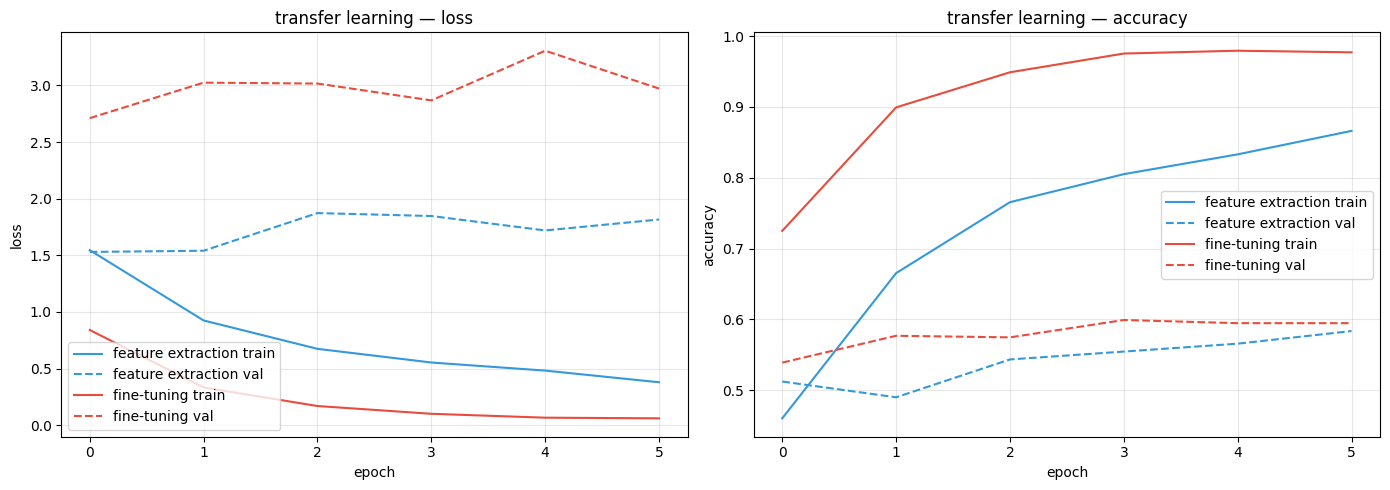

In [ ]:
# Visualizes training performance of transfer learning (feature extraction vs fine-tuning)
# by comparing loss and accuracy curves across both training phases.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Loss comparison ----------------
axes[0].plot(history_transfer.history["loss"], label="Feature Extract Train", color="blue")
axes[0].plot(history_transfer.history["val_loss"], label="Feature Extract Val", linestyle="--", color="blue")

axes[0].plot(history_finetune.history["loss"], label="Fine-tune Train", color="red")
axes[0].plot(history_finetune.history["val_loss"], label="Fine-tune Val", linestyle="--", color="red")

axes[0].set_title("Transfer Learning - Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------- Accuracy comparison ----------------
axes[1].plot(history_transfer.history["accuracy"], label="Feature Extract Train", color="blue")
axes[1].plot(history_transfer.history["val_accuracy"], label="Feature Extract Val", linestyle="--", color="blue")

axes[1].plot(history_finetune.history["accuracy"], label="Fine-tune Train", color="red")
axes[1].plot(history_finetune.history["val_accuracy"], label="Fine-tune Val", linestyle="--", color="red")

axes[1].set_title("Transfer Learning - Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig("transfer_learning_curves.png", dpi=150, bbox_inches="tight")

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 493ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        10
      basal cell carcinoma       0.36      0.86      0.51        35
            dermatofibroma       0.00      0.00      0.00        11
                  melanoma       0.74      0.56      0.64        50
                     nevus       0.69      0.69      0.69        45
pigmented benign keratosis       0.56      0.85      0.68        59
      seborrheic keratosis       0.00      0.00      0.00         7
   squamous cell carcinoma       0.00      0.00      0.00        23
           vascular lesion       1.00      0.12      0.21        17

                  accuracy                           0.55       257
                 macro avg       0.37      0.34      0.30       257
              weighted avg       0.51      0.55      0.48       257



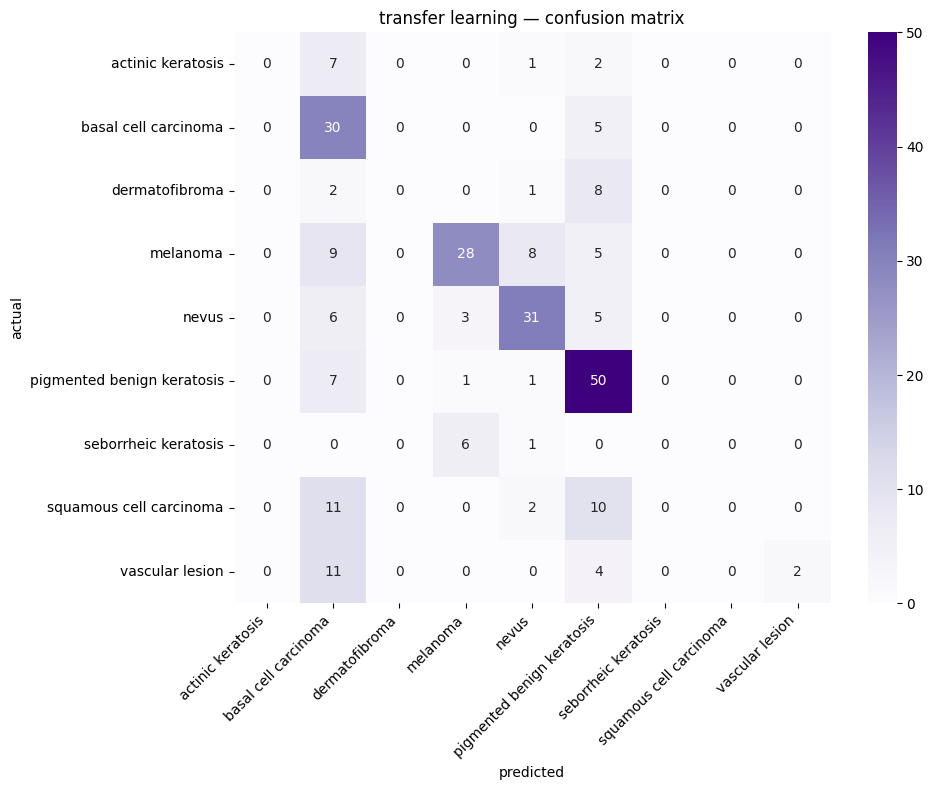

In [ ]:
# Evaluates transfer learning model performance on test dataset using classification report
# and visualizes results using a confusion matrix heatmap.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ---------------- Predictions ----------------
y_pred_transfer = np.argmax(transfer_model.predict(test_ds), axis=1)

# ---------------- True labels ----------------
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

# ---------------- Classification report ----------------
print(
    classification_report(
        y_true,
        y_pred_transfer,
        target_names=class_names,
        zero_division=0
    )
)

# ---------------- Confusion matrix ----------------
cm = confusion_matrix(y_true, y_pred_transfer)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Transfer Learning - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("transfer_confusion_matrix.png", dpi=150, bbox_inches="tight")

plt.show()

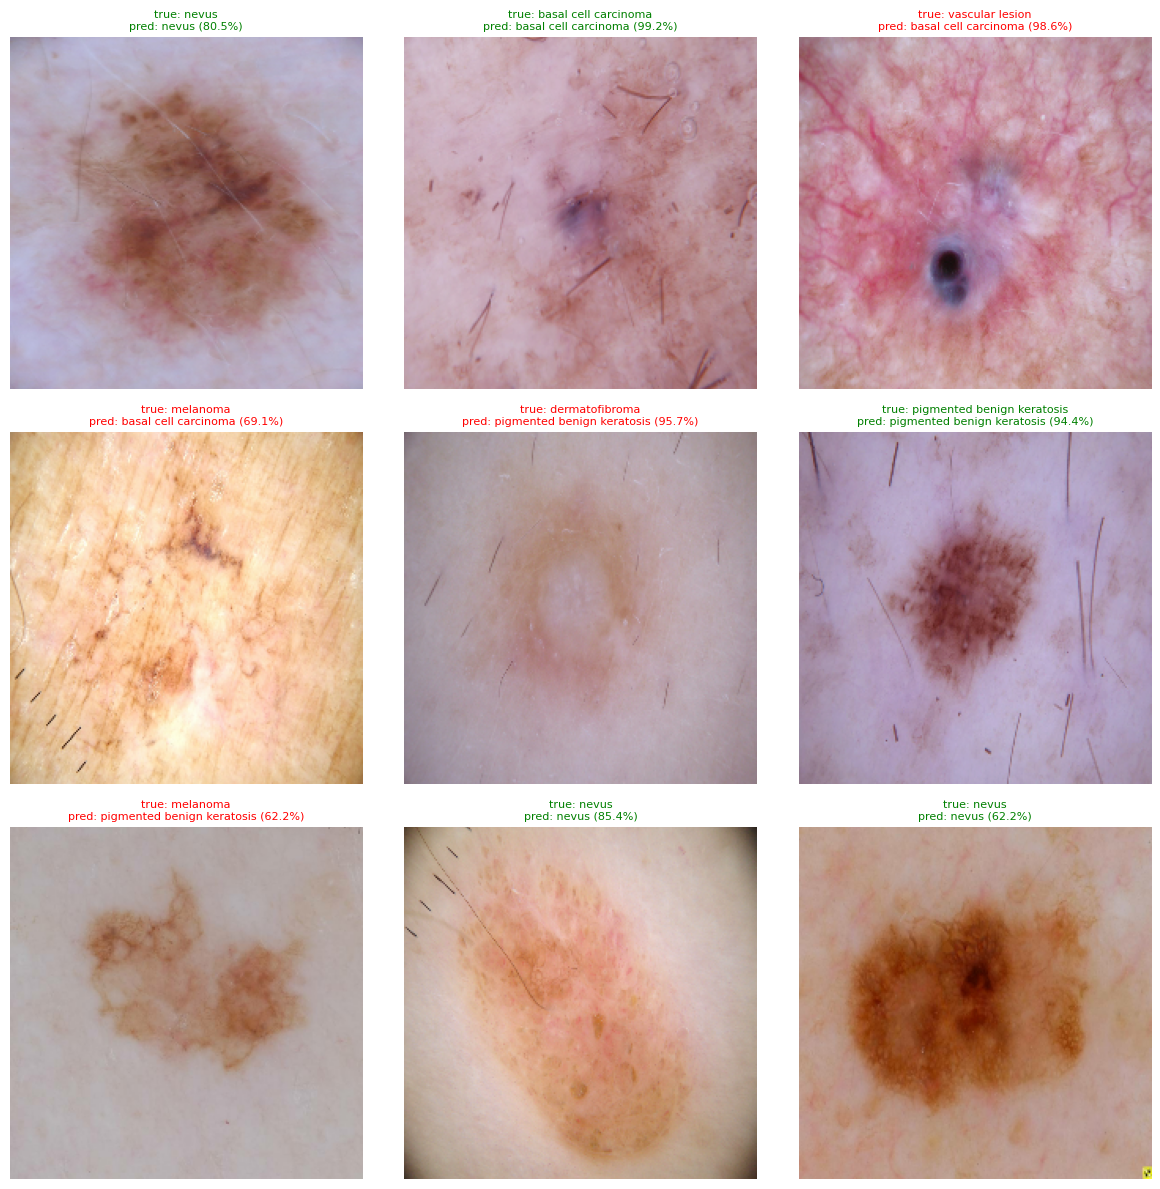

In [ ]:
# Displays sample predictions from the transfer learning model,
# comparing true labels vs predicted labels along with confidence scores
# for qualitative evaluation of model performance.

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# take one batch from test dataset
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    true_labels = np.argmax(labels.numpy(), axis=1)

    preds = transfer_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

# plot results
for i, ax in enumerate(axes.flat):

    img = (sample_images[i] * 255).astype("uint8")

    true_name = class_names[true_labels[i]]
    pred_name = class_names[pred_labels[i]]
    confidence = preds[i][pred_labels[i]] * 100

    ax.imshow(img)
    ax.axis("off")

    color = "green" if true_name == pred_name else "red"

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)",
        fontsize=8,
        color=color
    )

plt.tight_layout()

plt.savefig("transfer_sample_predictions.png", dpi=150, bbox_inches="tight")

plt.show()

In [ ]:
# Final evaluation comparing baseline CNN, deeper CNN, and transfer learning (ResNet50)
# using sklearn metrics for a fair weighted comparison across all models.

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------- Predictions ----------------
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)
y_pred_d = np.argmax(deeper_model.predict(test_ds, verbose=0), axis=1)
y_pred_t = np.argmax(transfer_model.predict(test_ds, verbose=0), axis=1)

# true labels
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

# ---------------- Metric function ----------------
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1 score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

# ---------------- Compute metrics ----------------
metrics_baseline = compute_metrics(y_true, y_pred_b)
metrics_deeper   = compute_metrics(y_true, y_pred_d)
metrics_transfer = compute_metrics(y_true, y_pred_t)

# ---------------- Create comparison table ----------------
comparison_df = pd.DataFrame({
    "Metric": list(metrics_baseline.keys()),
    "Baseline": [f"{v:.4f}" for v in metrics_baseline.values()],
    "Deeper": [f"{v:.4f}" for v in metrics_deeper.values()],
    "Transfer": [f"{v:.4f}" for v in metrics_transfer.values()]
})

# ---------------- Display ----------------
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


   metric baseline deeper transfer
 accuracy   0.4553 0.4086   0.5486
precision   0.4652 0.4143   0.5083
   recall   0.4553 0.4086   0.5486
 f1 score   0.4411 0.3875   0.4827
